<a href="https://colab.research.google.com/github/SadikshyaShres/Marketing-Capstone-Project/blob/main/SAAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Step 1 Data Transformation & ETL- — Transform variables
import pandas as pd
import numpy as np

#Visulization
import matplotlib.pyplot as plt
import seaborn as sns

#Machine Learning

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score,f1_score, roc_auc_score, precision_score, recall_score, classification_report

In [ ]:
#Step 2 : Data Acquisition
#loading data
accounts = pd.read_csv("ravenstack_accounts.csv")
subscriptions = pd.read_csv("ravenstack_subscriptions.csv")
usage = pd.read_csv("ravenstack_feature_usage.csv")
tickets = pd.read_csv("ravenstack_support_tickets.csv")
churn_events = pd.read_csv("ravenstack_churn_events.csv")

In [ ]:
#Step 3: Intial Data Assesment
print("=== RAW TABLE SHAPES ===")
print("ACCOUNTS:", accounts.shape)
print("SUBSCRIPTIONS:", subscriptions.shape)
print("USAGE:", usage.shape)
print("TICKETS:", tickets.shape)
print("CHURN EVENTS:", churn_events.shape)

print("\n=== ACCOUNTS HEAD ===")
display(accounts.head())

=== RAW TABLE SHAPES ===
ACCOUNTS: (500, 10)
SUBSCRIPTIONS: (5000, 14)
USAGE: (25000, 8)
TICKETS: (2000, 9)
CHURN EVENTS: (600, 9)

=== ACCOUNTS HEAD ===


,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False
1,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,False,True
2,A-0a282f,Company_2,DevTools,US,2024-08-27,organic,Basic,1,False,False
3,A-1f0ac7,Company_3,HealthTech,UK,2023-08-27,other,Basic,24,True,False
4,A-ce550d,Company_4,HealthTech,US,2024-10-27,event,Enterprise,35,False,True


In [ ]:
#merge subscription + churn events to accounts
df = accounts.merge(subscriptions, on="account_id", how="left")
df = df.merge(churn_events, on="account_id", how="left")

print("\n=== BASE MERGED SHAPE (accounts + subscriptions + churn events) ===")
print(df.shape)


=== BASE MERGED SHAPE (accounts + subscriptions + churn events) ===
(7429, 31)


In [ ]:
#Step 5: Data Transformation & ETL — Transform variables (encoding/scaling/type fixes) to make data model-ready.
usage_with_account = usage.merge(
    subscriptions[["subscription_id", "account_id"]],
    on="subscription_id",
    how="left"
)

usage_agg = usage_with_account.groupby("account_id").agg(
    feature_events=("feature_name", "count"),
    total_feature_usage=("usage_count", "sum")
).reset_index()

# Merge usage aggregates into df
df = df.merge(usage_agg, on="account_id", how="left")

In [ ]:
#Step 6: Initial Data Assessment — Quickly inspect structure, types, and basic summaries.
#support ticket
tickets_agg = tickets.groupby("account_id").agg(
    support_ticket_count=("ticket_id", "count")
).reset_index()

df = df.merge(tickets_agg, on="account_id", how="left")

print("\n=== FINAL MERGED SHAPE (includes usage + tickets) ===")
print(df.shape)



=== FINAL MERGED SHAPE (includes usage + tickets) ===
(7429, 34)


In [ ]:
## Step 7: Initial Data Assessment — Quickly inspect structure, types, and basic summaries.
#target variable
df["Churn"] = np.where(df["churn_date"].isna(), 0, 1)

print("\n=== CHURN VALUE COUNTS (0=Active, 1=Churned) ===")
print(df["Churn"].value_counts())



=== CHURN VALUE COUNTS (0=Active, 1=Churned) ===
Churn
1    5957
0    1472
Name: count, dtype: int64


In [ ]:
#drop churn_rate
if "churn_date" in df.columns:
    df.drop(columns=["churn_date"], inplace=True)
else:
    print("Column 'churn_date' not found in DataFrame. Skipping drop operation.")

In [ ]:
#step 8: Data Cleaning - handling missing values
missing_count = df.isna().sum()
missing_pct = (missing_count / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing_Count": missing_count,
    "Missing_Percentage": missing_pct.round(2)
})



In [ ]:
#Handling missing values
for col in ["feature_events", "total_feature_usage", "support_ticket_count"]:
    if col in df.columns:
        df[col] = df[col].fillna(0)



In [ ]:
#Checking Duplicates

dup_count = df.duplicated().sum()
print("\n=== DUPLICATE ROWS ===")
print(dup_count)


=== DUPLICATE ROWS ===
0


In [ ]:
#descriptive stats

print("\n=== DESCRIPTIVE STATISTICS (Numeric Columns) ===")
display(df.describe().T)


=== DESCRIPTIVE STATISTICS (Numeric Columns) ===


,count,mean,std,min,25%,50%,75%,max
seats_x,7429.0,19.637098,20.056153,1.0,5.0,14.0,27.0,163.00
seats_y,7429.0,29.371382,22.609002,1.0,13.0,24.0,40.0,189.00
mrr_amount,7429.0,2226.332346,3337.186814,0.0,266.0,882.0,2744.0,33830.00
arr_amount,7429.0,26715.988155,40046.241768,0.0,3192.0,10584.0,32928.0,405960.00
refund_amount_usd,5957.0,13.842432,37.843432,0.0,0.0,0.0,0.0,392.92
feature_events,7429.0,54.787185,16.499770,10.0,43.0,55.0,67.0,101.00
total_feature_usage,7429.0,548.729439,167.196015,92.0,435.0,552.0,666.0,1053.00
support_ticket_count,7429.0,3.975232,1.783497,0.0,3.0,4.0,5.0,11.00
Churn,7429.0,0.801858,0.398627,0.0,1.0,1.0,1.0,1.00


In [ ]:
#data dictonary

saas_data_dictionary = pd.DataFrame({
    "Variable": df.columns,
    "Data_Type": df.dtypes.astype(str),
    "Unique_Values": [df[c].nunique() for c in df.columns],
    "Sample_Values": [df[c].dropna().unique()[:5] for c in df.columns]
})

print("\n=== DATA DICTIONARY (Preview) ===")
display(saas_data_dictionary.head())


=== DATA DICTIONARY (Preview) ===


,Variable,Data_Type,Unique_Values,Sample_Values
account_id,account_id,object,500,"[A-2e4581, A-43a9e3, A-0a282f, A-1f0ac7, A-ce5..."
account_name,account_name,object,500,"[Company_0, Company_1, Company_2, Company_3, C..."
industry,industry,object,5,"[EdTech, FinTech, DevTools, HealthTech, Cybers..."
country,country,object,7,"[US, IN, UK, CA, DE]"
signup_date,signup_date,object,370,"[2024-10-16, 2023-08-17, 2024-08-27, 2023-08-2..."


In [ ]:
#save output

df.to_csv("saas_churn_clean.csv", index=False)
saas_data_dictionary.to_csv("saas_data_dictionary.csv", index=False)

print("\nSAVED FILES: saas_churn_clean.csv | saas_data_dictionary.csv")


SAVED FILES: saas_churn_clean.csv | saas_data_dictionary.csv


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#decriptive statistics

print("Dataset Structure")
display("Dataset Shape:",df.shape)
print("\nDatatypes")
display(df.info())

print("\nNumeric Summary")
display(df.describe().T)

print("\nChurn Distribution")
print(df["Churn"].value_counts())
print(df["Churn"].value_counts(normalize=True))

#mean compairson by churn

num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols.remove("Churn")

print("\nMean Comparison by Churn")
display(df.groupby("Churn")[num_cols].mean())

Dataset Structure


'Dataset Shape:'

(7429, 34)


Datatypes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7429 entries, 0 to 7428
Data columns (total 34 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   account_id                7429 non-null   object 
 1   account_name              7429 non-null   object 
 2   industry                  7429 non-null   object 
 3   country                   7429 non-null   object 
 4   signup_date               7429 non-null   object 
 5   referral_source           7429 non-null   object 
 6   plan_tier_x               7429 non-null   object 
 7   seats_x                   7429 non-null   int64  
 8   is_trial_x                7429 non-null   bool   
 9   churn_flag_x              7429 non-null   bool   
 10  subscription_id           7429 non-null   object 
 11  start_date                7429 non-null   object 
 12  end_date                  735 non-null    object 
 13  plan_tier_y               7429 non-null   object 
 1

None


Numeric Summary


,count,mean,std,min,25%,50%,75%,max
seats_x,7429.0,19.637098,20.056153,1.0,5.0,14.0,27.0,163.00
seats_y,7429.0,29.371382,22.609002,1.0,13.0,24.0,40.0,189.00
mrr_amount,7429.0,2226.332346,3337.186814,0.0,266.0,882.0,2744.0,33830.00
arr_amount,7429.0,26715.988155,40046.241768,0.0,3192.0,10584.0,32928.0,405960.00
refund_amount_usd,5957.0,13.842432,37.843432,0.0,0.0,0.0,0.0,392.92
feature_events,7429.0,54.787185,16.499770,10.0,43.0,55.0,67.0,101.00
total_feature_usage,7429.0,548.729439,167.196015,92.0,435.0,552.0,666.0,1053.00
support_ticket_count,7429.0,3.975232,1.783497,0.0,3.0,4.0,5.0,11.00
Churn,7429.0,0.801858,0.398627,0.0,1.0,1.0,1.0,1.00



Churn Distribution
Churn
1    5957
0    1472
Name: count, dtype: int64
Churn
1    0.801858
0    0.198142
Name: proportion, dtype: float64

Mean Comparison by Churn


,seats_x,seats_y,mrr_amount,arr_amount,refund_amount_usd,feature_events,total_feature_usage,support_ticket_count
Churn,,,,,,,,
0,20.684783,30.451087,2274.296875,27291.562500,NaN,53.810462,539.796196,4.114810
1,19.378211,29.104583,2214.480107,26573.761289,13.842432,55.028538,550.936881,3.940742


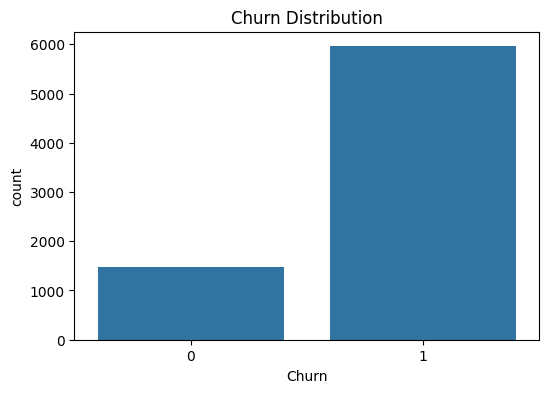

feature_events


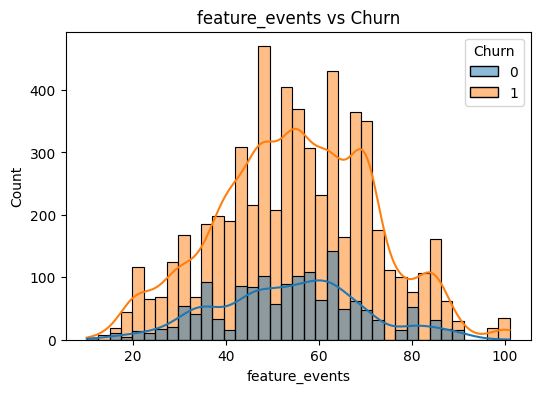

total_feature_usage


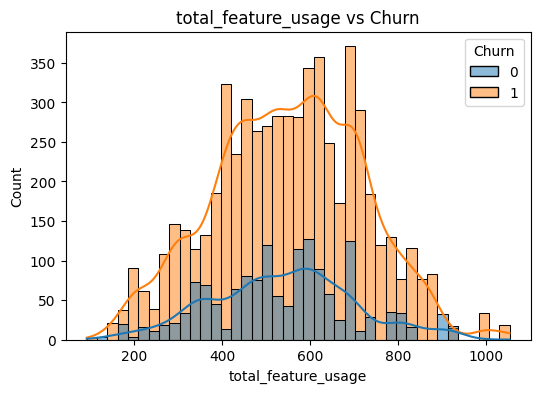

support_ticket_count


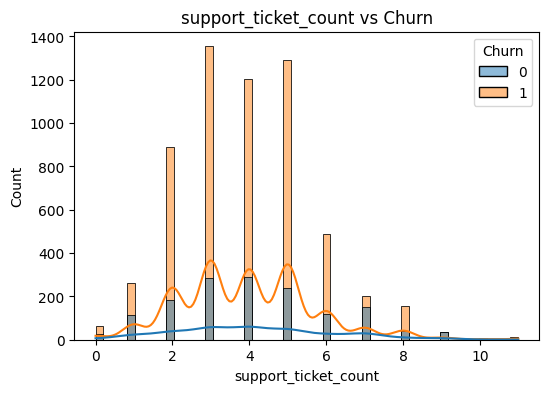

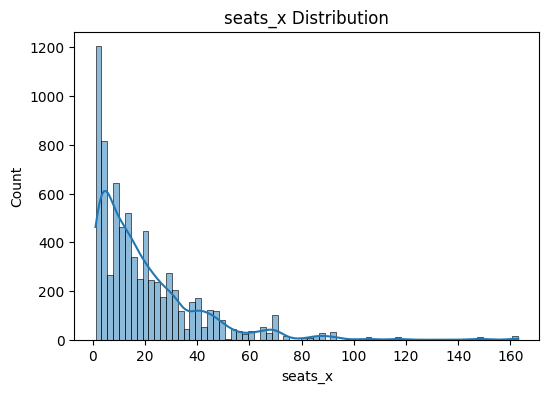

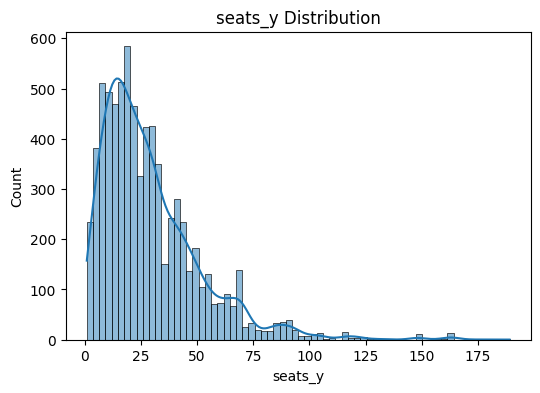

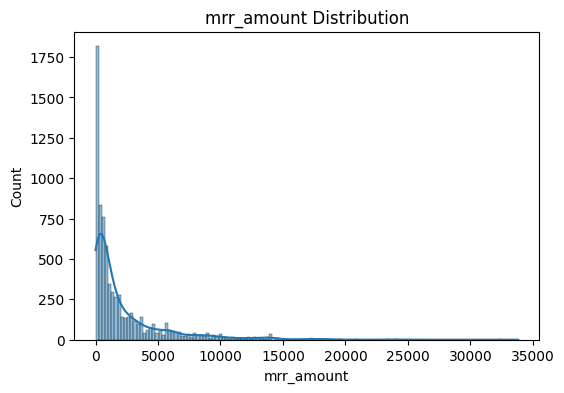

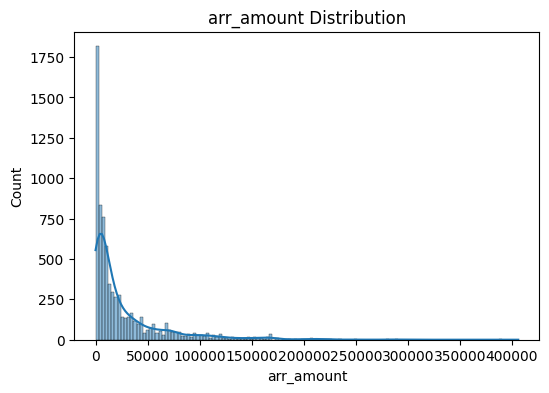

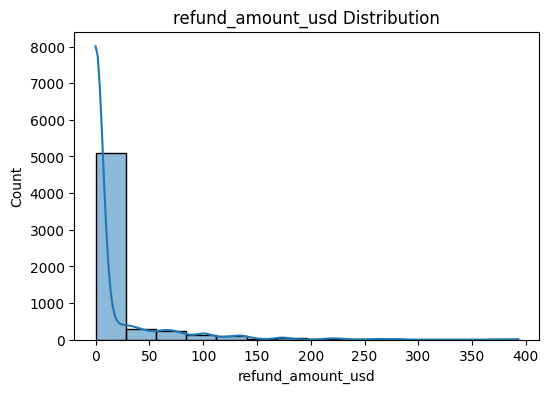

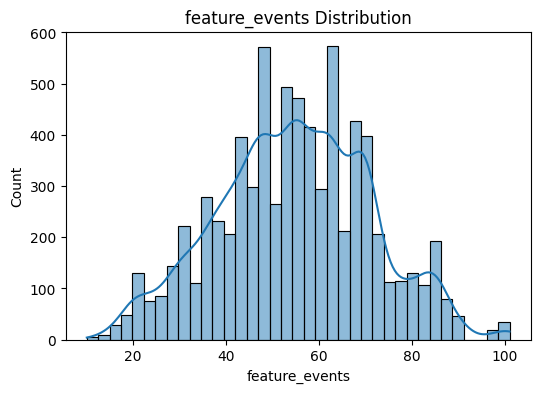

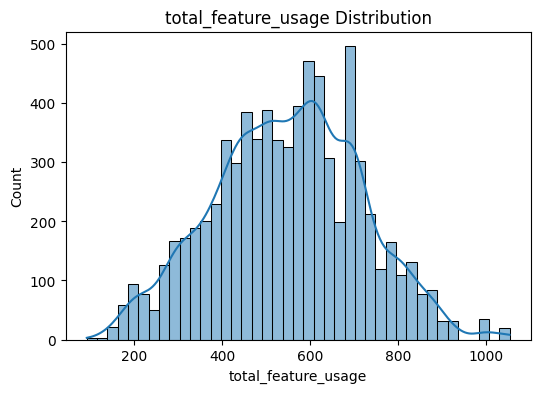

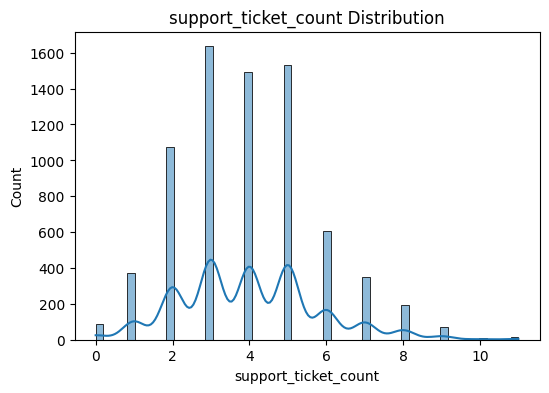

In [ ]:
#EDA

#churn distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Churn")
plt.title("Churn Distribution")
plt.show()

#usage behaviour analysis

important_usage = ["feature_events","total_feature_usage","support_ticket_count"]
for col in important_usage:
    plt.figure(figsize=(6, 4))
    sns.histplot(data=df, x=col, hue="Churn", kde=True)
    print(col)
    plt.title(f"{col} vs Churn")
    plt.show()

#numeric distribution

for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f"{col} Distribution")
    plt.show()

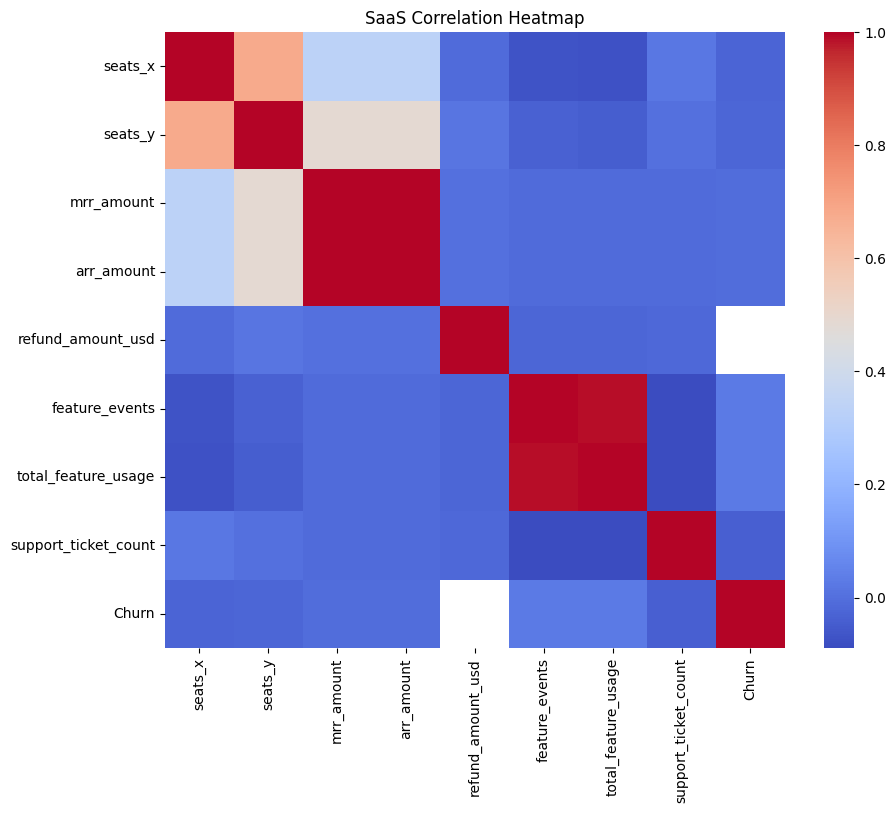

In [ ]:
import numpy as np

#correlation heatmap

plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), cmap="coolwarm")
plt.title("SaaS Correlation Heatmap")
plt.show()

In [ ]:
#encoding for modeling

columns_to_drop = [
    'account_id', 'account_name', 'subscription_id', 'signup_date', 'start_date',
    'end_date', 'churn_event_id', 'reason_code', 'refund_amount_usd',
    'preceding_upgrade_flag', 'preceding_downgrade_flag', 'is_reactivation',
    'feedback_text', 'churn_flag_x', 'churn_flag_y' # Include churn_flag_x and churn_flag_y here as well
]
df_model = pd.get_dummies(df.drop(columns=columns_to_drop), drop_first=True)

# Fill any remaining NaNs in df_model before splitting and scaling
df_model = df_model.fillna(0)

print("Shape after encoding:", df_model.shape)

Shape after encoding: (7429, 32)


In [ ]:
#train test split

X = df_model.drop("Churn", axis=1)
y = df_model["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
#logistic Regression

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.transform(X_test)

In [ ]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(x_train_scaled, y_train)

y_preb_log = log_model.predict(x_test_scaled)
y_prob_log = log_model.predict_proba(x_test_scaled)[:, 1]

print("Logistic Regression Result")

print("Accuracy:", accuracy_score(y_test, y_preb_log))
print("Precision:", precision_score(y_test, y_preb_log))
print("Recall:", recall_score(y_test, y_preb_log))
print("F1 Score:", f1_score(y_test, y_preb_log))
print("ROC AUC Score:", roc_auc_score(y_test, y_prob_log))

Logistic Regression Result
Accuracy: 0.8021534320323015
Precision: 0.8021534320323015
Recall: 1.0
F1 Score: 0.8902165795369679
ROC AUC Score: 0.6053365977263389


In [ ]:
#Decision Tree

tree_model = DecisionTreeClassifier(max_depth = 5 , random_state=42)
tree_model.fit(x_train_scaled, y_train)

y_pred_tree = tree_model.predict(x_test_scaled)
y_prob_tree = tree_model.predict_proba(x_test_scaled)[:, 1]

print("Decision Tree Result")

print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print("Precision:", precision_score(y_test, y_pred_tree))
print("Recall:", recall_score(y_test, y_pred_tree))
print("F1 Score:", f1_score(y_test, y_pred_tree))
print("ROC AUC Score:", roc_auc_score(y_test, y_prob_tree))

Decision Tree Result
Accuracy: 0.8425302826379543
Precision: 0.838276836158192
Recall: 0.9958053691275168
F1 Score: 0.9102760736196319
ROC AUC Score: 0.6924636465324384


In [ ]:
#Random Forest

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)

rf_model.fit(x_train_scaled, y_train)

y_pred_rf = rf_model.predict(x_test_scaled)
y_prob_rf = rf_model.predict_proba(x_test_scaled)[:,1]

print("RANDOM FOREST RESULTS")

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1:", f1_score(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_prob_rf))

RANDOM FOREST RESULTS
Accuracy: 0.9979811574697174
Precision: 0.9974895397489539
Recall: 1.0
F1: 0.9987431922915794
ROC AUC: 1.0


In [ ]:
#model comparison

saas_model_comparison = pd.DataFrame({
    "Model":["Logistic Regression","Decision Tree","Random Forest"],
    "Accuracy":[
        accuracy_score(y_test, y_preb_log),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision":[
        precision_score(y_test, y_preb_log),
        precision_score(y_test, y_pred_tree),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall":[
        recall_score(y_test, y_preb_log),
        recall_score(y_test, y_pred_tree),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score":[
        f1_score(y_test, y_preb_log),
        f1_score(y_test, y_pred_tree),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC AUC":[
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_tree),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

display(saas_model_comparison)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.802153,0.802153,1.000000,0.890217,0.605337
1,Decision Tree,0.842530,0.838277,0.995805,0.910276,0.692464
2,Random Forest,0.997981,0.997490,1.000000,0.998743,1.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


,Risk_Segment,Customer_Count
0,Low Risk,NaN
1,Medium Risk,1332.0
2,High Risk,154.0


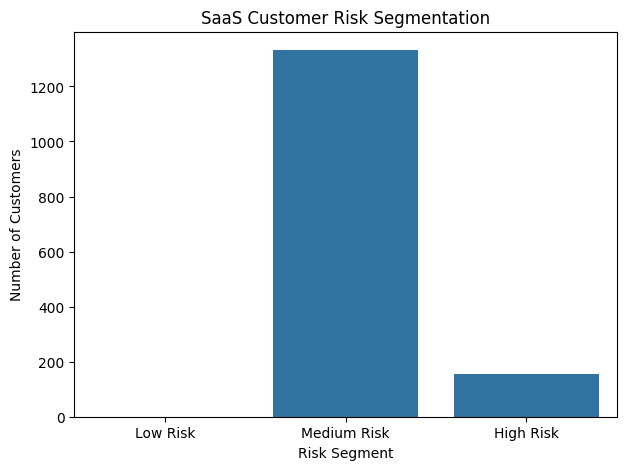

Saved: saas_risk_segmentation_tableau.csv
Saved: saas_segment_summary_tableau.csv


In [ ]:
#SaaS Customer Segmentation

# Predicted class and probability
y_pred_rf_saas = rf_model.predict(X_test)
y_prob_rf_saas = rf_model.predict_proba(X_test)[:, 1]

# Create segmentation dataframe
saas_segmentation = df.loc[X_test.index].copy()
saas_segmentation["Actual_Churn"] = y_test.values
saas_segmentation["Predicted_Churn"] = y_pred_rf_saas
saas_segmentation["Churn_Probability"] = y_prob_rf_saas

# Risk segmentation
def risk_segment(prob):
    if prob < 0.33:
        return "Low Risk"
    elif prob < 0.66:
        return "Medium Risk"
    else:
        return "High Risk"

saas_segmentation["Risk_Segment"] = saas_segmentation["Churn_Probability"].apply(risk_segment)

# Segment summary
saas_segment_summary = (
    saas_segmentation["Risk_Segment"]
    .value_counts()
    .reindex(["Low Risk", "Medium Risk", "High Risk"])
    .reset_index()
)
saas_segment_summary.columns = ["Risk_Segment", "Customer_Count"]

display(saas_segment_summary)

# Bar chart
plt.figure(figsize=(7, 5))
sns.barplot(data=saas_segment_summary, x="Risk_Segment", y="Customer_Count")
plt.title("SaaS Customer Risk Segmentation")
plt.xlabel("Risk Segment")
plt.ylabel("Number of Customers")
plt.show()

# Save for Tableau
saas_segmentation.to_csv("saas_risk_segmentation_tableau.csv", index=False)
saas_segment_summary.to_csv("saas_segment_summary_tableau.csv", index=False)

print("Saved: saas_risk_segmentation_tableau.csv")
print("Saved: saas_segment_summary_tableau.csv")

In [ ]:
df.to_csv("saas_churn_tableau_output.csv", index=False)

saas_model_comparison.to_csv("saas_model_perfomance.csv", index=False)

In [ ]:
#Hyperparameter Optmization

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve

In [ ]:
#Logistic Regression Tuning
lr_param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["liblinear", "lbfgs"],
    "penalty": ["l2"]
}

lr_grid = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000),
    param_grid=lr_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

lr_grid.fit(x_train_scaled, y_train)

best_lr_model = lr_grid.best_estimator_

print("Best Logistic Regression Parameters:")
print(lr_grid.best_params_)

best_pred_lr = best_lr_model.predict(x_test_scaled)
best_prob_lr = best_lr_model.predict_proba(x_test_scaled)[:, 1]

Best Logistic Regression Parameters:
{'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}


In [ ]:
#Decision Tree Tuning
dt_param_grid = {
    "max_depth": [3, 5, 7, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5]
}

dt_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=dt_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

best_dt_model = dt_grid.best_estimator_

print("Best Decision Tree Parameters:")
print(dt_grid.best_params_)

best_pred_dt = best_dt_model.predict(X_test)
best_prob_dt = best_dt_model.predict_proba(X_test)[:, 1]

Best Decision Tree Parameters:
{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10}


In [ ]:
#Random Forest Tuning
rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

best_rf_model = rf_grid.best_estimator_

print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

best_pred_rf = best_rf_model.predict(X_test)
best_prob_rf = best_rf_model.predict_proba(X_test)[:, 1]

Best Random Forest Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}


In [ ]:
saas_optimized_results = pd.DataFrame({
    "Model": [
        "Optimized Logistic Regression",
        "Optimized Decision Tree",
        "Optimized Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, best_pred_lr),
        accuracy_score(y_test, best_pred_dt),
        accuracy_score(y_test, best_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, best_pred_lr),
        precision_score(y_test, best_pred_dt),
        precision_score(y_test, best_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, best_pred_lr),
        recall_score(y_test, best_pred_dt),
        recall_score(y_test, best_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, best_pred_lr),
        f1_score(y_test, best_pred_dt),
        f1_score(y_test, best_pred_rf)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, best_prob_lr),
        roc_auc_score(y_test, best_prob_dt),
        roc_auc_score(y_test, best_prob_rf)
    ]
})

print("SaaS Optimized Model Performance")
display(saas_optimized_results)

SaaS Optimized Model Performance


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Optimized Logistic Regression,0.802153,0.802153,1.000000,0.890217,0.605337
1,Optimized Decision Tree,0.913863,0.933225,0.961409,0.947107,0.941004
2,Optimized Random Forest,0.997308,0.996656,1.000000,0.998325,1.000000
